<a href="https://colab.research.google.com/github/14marcos1/projeto2026/blob/main/projeto1_mapas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Acessando mapas do IBGE...


/tmp/ipykernel_220/1775011521.py:58: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(mapa_final.geometry.centroid.x, mapa_final.geometry.centroid.y, mapa_final.Município):


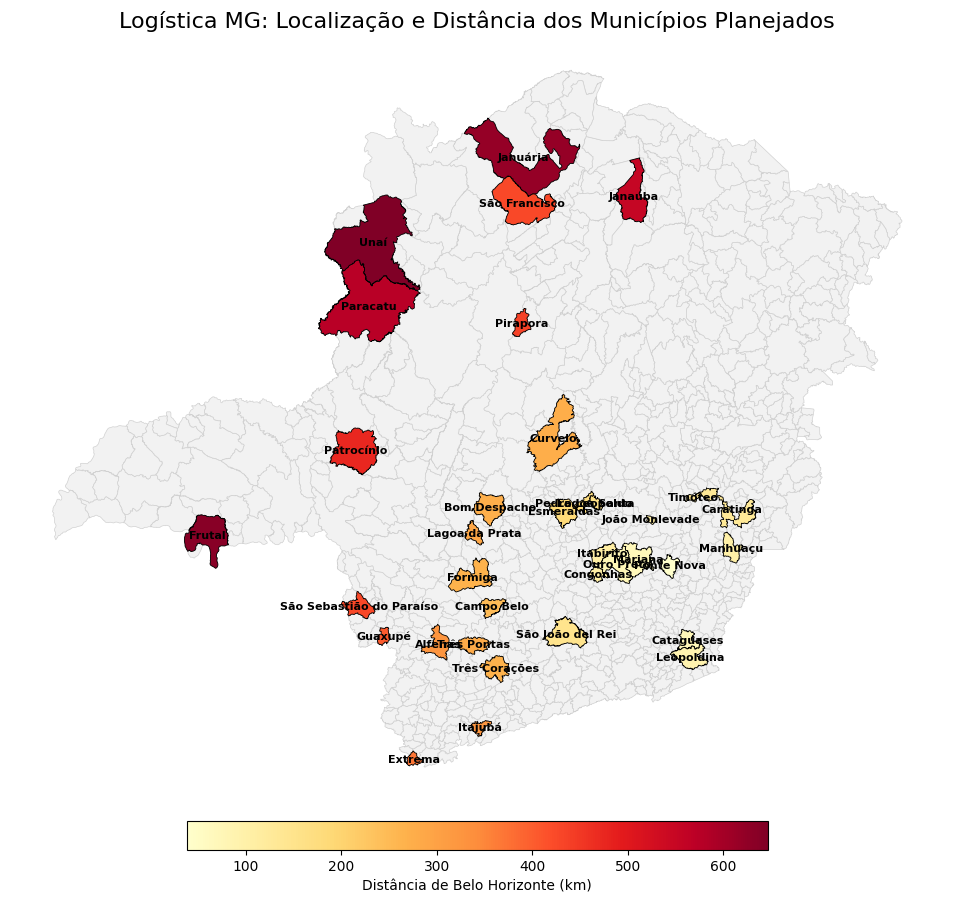

In [9]:
import pandas as pd
import geobr
import geopandas as gpd
import matplotlib.pyplot as plt
from unidecode import unidecode
import os

# 1. Nome do arquivo original
file_name = 'Planejamento_Municipios_MG.xlsx'

if not os.path.exists(file_name):
    print(f"ERRO: O arquivo '{file_name}' não foi encontrado na aba lateral.")
else:
    # 2. Carregar as abas específicas do Excel
    # O pandas lê cada aba como um DataFrame diferente
    df_distancias = pd.read_excel(file_name, sheet_name='Distancias_Tempos')
    df_regioes_raw = pd.read_excel(file_name, sheet_name='Resumo_por_Regiao')

    # 3. Processar as regiões (separar cidades que estão na mesma célula por vírgula)
    df_regioes = df_regioes_raw.assign(Municípios=df_regioes_raw['Municípios'].str.split(', ')).explode('Municípios')
    df_regioes = df_regioes.rename(columns={'Municípios': 'Município'})

    # 4. Unificar os dados (Distâncias + Regiões)
    df_total = pd.merge(df_distancias, df_regioes[['Município', 'Região']], on='Município', how='left')

    # 5. Baixar o mapa de Minas Gerais via IBGE
    print("Acessando mapas do IBGE...")
    mg_map = geobr.read_municipality(code_muni="MG", year=2020)

    # 6. Normalização para o cruzamento de dados
    def normalize_text(text):
        return unidecode(str(text)).upper().strip()

    mg_map['name_muni_norm'] = mg_map['name_muni'].apply(normalize_text)
    df_total['name_muni_norm'] = df_total['Município'].apply(normalize_text)

    # 7. Mesclar os seus dados com as coordenadas geográficas
    mapa_final = mg_map.merge(df_total, on='name_muni_norm', how='left')

    # 8. Gerar a visualização
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))

    # Desenhar fundo de MG
    mg_map.plot(ax=ax, color='#f2f2f2', edgecolor='#d1d1d1', linewidth=0.5)

    # Colorir cidades do planejamento (por distância)
    mapa_final.dropna(subset=['Distância (km)']).plot(
        column='Distância (km)',
        ax=ax,
        legend=True,
        cmap='YlOrRd',
        legend_kwds={'label': "Distância de Belo Horizonte (km)", 'orientation': "horizontal", 'pad': 0.02, 'shrink': 0.5},
        edgecolor='black',
        linewidth=0.6
    )

    # Adicionar nomes das cidades no mapa
    for x, y, label in zip(mapa_final.geometry.centroid.x, mapa_final.geometry.centroid.y, mapa_final.Município):
        if pd.notnull(label):
            ax.text(x, y, label, fontsize=8, ha='center', va='center', weight='bold')

    plt.title('Logística MG: Localização e Distância dos Municípios Planejados', fontsize=16)
    ax.axis('off')
    plt.show()

Baixando mapas do IBGE... (Isso pode levar alguns segundos)


/tmp/ipykernel_220/190346837.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mg_map['centroid'] = mg_map.geometry.centroid


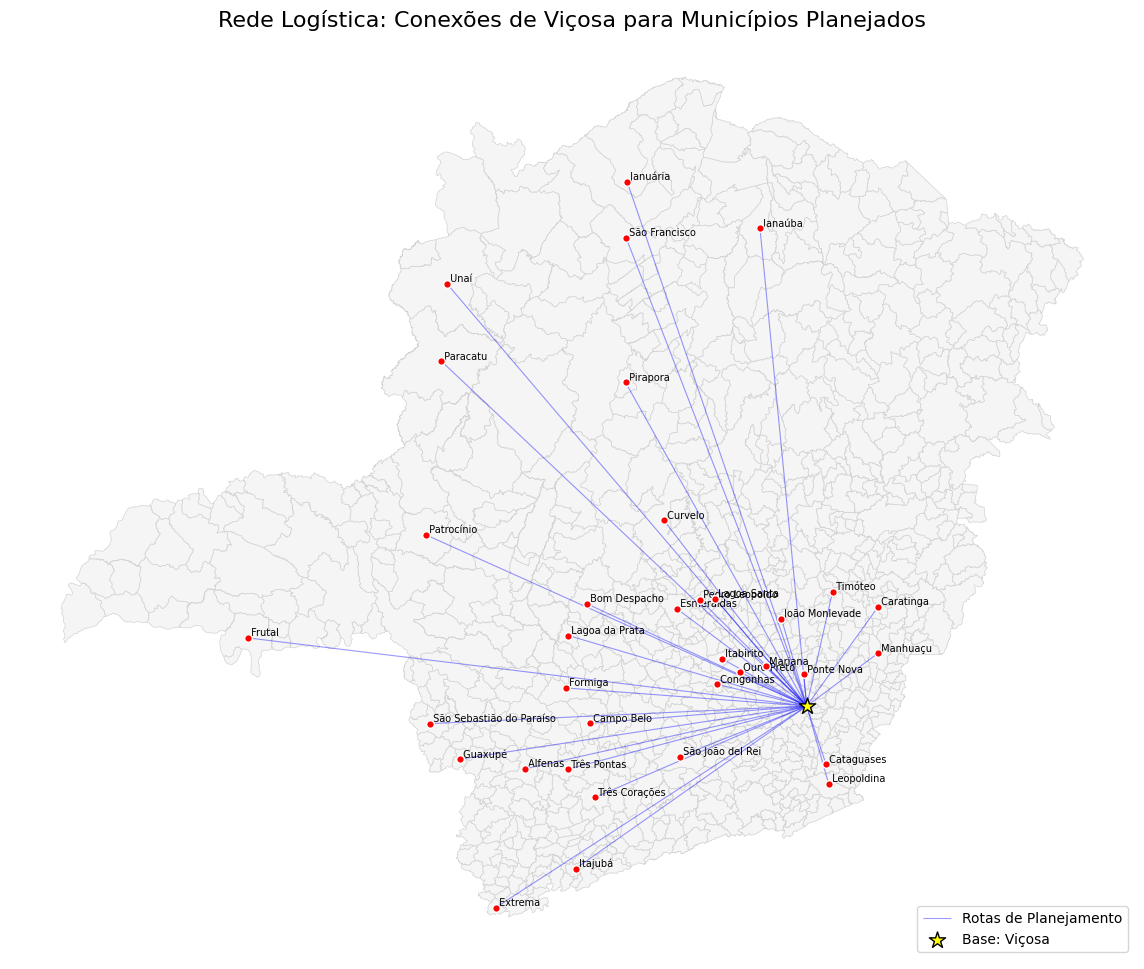

In [10]:
import pandas as pd
import geobr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from unidecode import unidecode
import os

# 1. Configurações Iniciais
file_name = 'Planejamento_Municipios_MG.xlsx'
cidade_origem = "Viçosa"

# 2. Carregar os Dados
if not os.path.exists(file_name):
    print(f"Erro: O arquivo '{file_name}' não foi encontrado.")
else:
    # Lendo as abas do seu Excel
    df_distancias = pd.read_excel(file_name, sheet_name='Distancias_Tempos')

    # 3. Baixar Mapas do IBGE
    print("Baixando mapas do IBGE... (Isso pode levar alguns segundos)")
    mg_map = geobr.read_municipality(code_muni="MG", year=2020)

    # Normalização de nomes para garantir o cruzamento
    def normalize(text):
        return unidecode(str(text)).upper().strip()

    mg_map['name_norm'] = mg_map['name_muni'].apply(normalize)
    df_distancias['name_norm'] = df_distancias['Município'].apply(normalize)
    origem_norm = normalize(cidade_origem)

    # 4. Obter Coordenadas (Centróides)
    # Pegar o ponto central de cada município
    mg_map['centroid'] = mg_map.geometry.centroid

    # Localizar o ponto de Viçosa
    ponto_origem = mg_map[mg_map['name_norm'] == origem_norm]['centroid'].values[0]

    # 5. Criar as Linhas de Ligação
    # Unir a tabela de distâncias com as geometrias do mapa
    df_geo = pd.merge(df_distancias, mg_map[['name_norm', 'centroid']], on='name_norm', how='inner')

    # Criar uma geometria de linha entre a origem e cada destino
    df_geo['line_geometry'] = df_geo['centroid'].apply(lambda x: LineString([ponto_origem, x]))

    # Criar um GeoDataFrame apenas para as linhas
    gdf_linhas = gpd.GeoDataFrame(df_geo, geometry='line_geometry', crs=mg_map.crs)

    # 6. Plotar o Mapa
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))

    # Desenhar o estado de MG ao fundo
    mg_map.plot(ax=ax, color='#f5f5f5', edgecolor='#d3d3d3', linewidth=0.5)

    # Desenhar as linhas de ligação
    gdf_linhas.plot(ax=ax, color='blue', linewidth=0.8, alpha=0.4, label='Rotas de Planejamento')

    # Destacar os municípios de destino
    df_geo_points = gpd.GeoDataFrame(df_geo, geometry='centroid', crs=mg_map.crs)
    df_geo_points.plot(ax=ax, color='red', markersize=30, edgecolor='white', zorder=5)

    # Destacar a cidade de ORIGEM (Viçosa)
    ax.scatter(ponto_origem.x, ponto_origem.y, color='yellow', s=150, edgecolor='black', marker='*', zorder=10, label=f'Base: {cidade_origem}')

    # Adicionar nomes das cidades principais
    for x, y, label in zip(df_geo_points.geometry.x, df_geo_points.geometry.y, df_geo_points.Município):
        ax.text(x, y, f" {label}", fontsize=7, verticalalignment='bottom')

    plt.title(f'Rede Logística: Conexões de {cidade_origem} para Municípios Planejados', fontsize=16)
    plt.legend(loc='lower right')
    ax.axis('off')
    plt.show()